# Datathon Fase 5 — Base Completa com Rotulagem de Sentimento por DistilBERT

Este notebook processa a base completa de reclamações financeiras, cria a variável alvo de sentimento com um modelo pré-treinado de linguagem, compara abordagens de modelagem e analisa as principais dores dos clientes.

## Objetivos
- realizar o pré-processamento textual das reclamações;
- criar a variável alvo de sentimento em formato binário (`positivo` e `negativo`);
- treinar um **baseline** com TF-IDF + Regressão Logística;
- treinar um modelo de **Deep Learning** com LSTM;
- analisar os principais temas das reclamações negativas por categoria de produto.

## Escolha do modelo de sentimento
Nesta versão, a rotulagem automática de sentimento é feita com o modelo **`distilbert/distilbert-base-uncased-finetuned-sst-2-english`**, um modelo de classificação de sentimento em inglês ajustado no conjunto SST-2. Ele retorna diretamente as classes `POSITIVE` e `NEGATIVE`, o que deixa a variável alvo mais aderente ao desafio proposto.

## 1. Instalações

In [ ]:

#!pip install nltk
#!pip install scikit-learn
#!pip install kagglehub pandas
#!pip install transformers
#!pip install tensorflow

## 2. Importações

In [1]:

import os
import re
import string
import unicodedata
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
import kagglehub
import torch
import time
import tensorflow as tf

from transformers import pipeline
from collections import Counter
from wordcloud import WordCloud

from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords

from sklearn.utils import shuffle
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
from sklearn.metrics import roc_curve, roc_auc_score, precision_recall_curve
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.utils.class_weight import compute_class_weight
from sklearn.feature_extraction.text import CountVectorizer

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.layers import GRU

## 3. Verificação da GPU

In [2]:

print("CUDA disponível:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("GPU não disponível")

CUDA disponível: False
GPU não disponível


## 4. Recursos do NLTK

In [3]:

nltk.download("punkt_tab")
nltk.download("stopwords")

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

## 5. Montagem do Google Drive e criação da pasta do projeto

In [8]:

from google.colab import drive
drive.mount('/content/drive')

PASTA_PROJETO = "/content/drive/MyDrive/artefatos_fase5_full_sst2"
os.makedirs(PASTA_PROJETO, exist_ok=True)

print("Pasta do projeto:", PASTA_PROJETO)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Pasta do projeto: /content/drive/MyDrive/artefatos_fase5_full_sst2


## 6. Funções auxiliares

In [5]:

def salvar_csv(df, nome_arquivo, pasta=PASTA_PROJETO):
    caminho = os.path.join(pasta, nome_arquivo)
    df.to_csv(caminho, index=False)
    print(f"Salvo: {caminho}")

def carregar_csv(nome_arquivo, pasta=PASTA_PROJETO):
    caminho = os.path.join(pasta, nome_arquivo)
    df = pd.read_csv(caminho)
    print(f"Carregado: {caminho}")
    return df

def salvar_objeto(obj, nome_arquivo, pasta=PASTA_PROJETO):
    caminho = os.path.join(pasta, nome_arquivo)
    joblib.dump(obj, caminho)
    print(f"Salvo: {caminho}")

def carregar_objeto(nome_arquivo, pasta=PASTA_PROJETO):
    caminho = os.path.join(pasta, nome_arquivo)
    obj = joblib.load(caminho)
    print(f"Carregado: {caminho}")
    return obj

## 7. Download da base

In [ ]:

path = kagglehub.dataset_download("shashwatwork/consume-complaints-dataset-fo-nlp")
print("Dataset salvo em:", path)
print("Arquivos encontrados:", os.listdir(path))

100%|██████████| 19.8M/19.8M [00:00<00:00, 99.8MB/s]

Extracting files...


Dataset salvo em: /root/.cache/kagglehub/datasets/shashwatwork/consume-complaints-dataset-fo-nlp/versions/1
Arquivos encontrados: ['complaints_processed.csv']


## 8. Leitura da base

In [ ]:

df = pd.read_csv(os.path.join(path, "complaints_processed.csv"))
df.head()

,Unnamed: 0,product,narrative
0,0,credit_card,purchase order day shipping amount receive pro...
1,1,credit_card,forwarded message date tue subject please inve...
2,2,retail_banking,forwarded message cc sent friday pdt subject f...
3,3,credit_reporting,payment history missing credit report speciali...
4,4,credit_reporting,payment history missing credit report made mis...


## 9. Inspeção inicial

In [ ]:

print("Dimensão:", df.shape)
print("Colunas:", df.columns.tolist())
print("\nInformações gerais:")
df.info()

print("\nValores nulos:")
print(df.isnull().sum())

Dimensão: (162421, 3)
Colunas: ['Unnamed: 0', 'product', 'narrative']

Informações gerais:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 162421 entries, 0 to 162420
Data columns (total 3 columns):
 #   Column      Non-Null Count   Dtype 
---  ------      --------------   ----- 
 0   Unnamed: 0  162421 non-null  int64 
 1   product     162421 non-null  object
 2   narrative   162411 non-null  object
dtypes: int64(1), object(2)
memory usage: 3.7+ MB

Valores nulos:
Unnamed: 0     0
product        0
narrative     10
dtype: int64


## 10. Limpeza estrutural

In [ ]:

df = df.drop(columns=["Unnamed: 0"], errors="ignore")
df = df.dropna(subset=["narrative"])
df = shuffle(df, random_state=42).reset_index(drop=True)

print("Nova dimensão:", df.shape)
df.head()

Nova dimensão: (162411, 2)


,product,narrative
0,mortgages_and_loans,called acima ask bill hold payment told date p...
1,credit_reporting,sent letter regarding inaccurate unknown thing...
2,mortgages_and_loans,purchased new vehicle alabama purchase price n...
3,debt_collection,contacted many time failed provide necessary d...
4,credit_card,cancellation trip emailed stating charge done ...


## 11. Base completa

In [ ]:

df_full = df.copy()
print("Dimensão da base completa:", df_full.shape)

Dimensão da base completa: (162411, 2)


## 12. Salvamento da base bruta

In [ ]:

salvar_csv(df_full, "01_full_bruta.csv")

Salvo: /content/drive/MyDrive/artefatos_fase5_full_sst2/01_full_bruta.csv


## 13. Funções de limpeza

São criadas duas versões do texto:

- **`narrative_classic`**: limpeza mais forte para o baseline clássico;
- **`narrative_dl`**: limpeza mais leve para preservar contexto no modelo de Deep Learning.

In [ ]:

stop_words = set(stopwords.words("english"))

def clean_text_classic(text):
    if not isinstance(text, str):
        return ""

    text = text.lower()
    text = unicodedata.normalize("NFKD", text).encode("ASCII", "ignore").decode("utf-8")
    text = re.sub(r"\d+", " ", text)
    text = text.translate(str.maketrans({p: " " for p in string.punctuation}))
    tokens = word_tokenize(text)
    tokens = [t for t in tokens if t not in stop_words]
    tokens = [t for t in tokens if len(t) > 2]
    return " ".join(tokens)

def clean_text_dl(text):
    if not isinstance(text, str):
        return ""

    text = text.lower().strip()
    text = re.sub(r"\s+", " ", text)
    return text

## 14. Aplicação da limpeza textual

In [ ]:

df_full["narrative_classic"] = df_full["narrative"].apply(clean_text_classic)
df_full["narrative_dl"] = df_full["narrative"].apply(clean_text_dl)

df_full[["narrative", "narrative_classic", "narrative_dl"]].head()

,narrative,narrative_classic,narrative_dl
0,called acima ask bill hold payment told date p...,called acima ask bill hold payment told date p...,called acima ask bill hold payment told date p...
1,sent letter regarding inaccurate unknown thing...,sent letter regarding inaccurate unknown thing...,sent letter regarding inaccurate unknown thing...
2,purchased new vehicle alabama purchase price n...,purchased new vehicle alabama purchase price n...,purchased new vehicle alabama purchase price n...
3,contacted many time failed provide necessary d...,contacted many time failed provide necessary d...,contacted many time failed provide necessary d...
4,cancellation trip emailed stating charge done ...,cancellation trip emailed stating charge done ...,cancellation trip emailed stating charge done ...


## 15. Salvamento da base tratada

In [ ]:

salvar_csv(df_full, "02_full_tratada.csv")

Salvo: /content/drive/MyDrive/artefatos_fase5_full_sst2/02_full_tratada.csv


## 16. Criação do modelo de sentimento

Nesta etapa, a variável alvo será gerada com o modelo **DistilBERT SST-2**, que retorna diretamente as classes `POSITIVE` e `NEGATIVE`.

In [ ]:

device = 0 if torch.cuda.is_available() else -1

sentiment_model = pipeline(
    "sentiment-analysis",
    model="distilbert/distilbert-base-uncased-finetuned-sst-2-english",
    device=device
)

print("Device do modelo:", sentiment_model.model.device)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/629 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

Device do modelo: cuda:0


## 17. Teste rápido do pipeline de sentimento

In [ ]:

amostra_teste = df_full["narrative_dl"].fillna("").astype(str).tolist()[:512]

ini = time.time()

_ = sentiment_model(
    amostra_teste,
    batch_size=32,
    truncation=True,
    max_length=128
)

fim = time.time()

print("Tempo para 512 textos:", fim - ini)
print("Device do modelo:", sentiment_model.model.device)

Tempo para 512 textos: 2.2276041507720947
Device do modelo: cuda:0


## 18. Inferência de sentimento na base completa

A base completa é processada em blocos para reduzir risco de erro de memória e manter o uso da GPU mais estável.

In [ ]:

textos = df_full["narrative_dl"].fillna("").astype(str).tolist()

resultados = []
batch_loop = 1000
batch_gpu = 32

for i in range(0, len(textos), batch_loop):
    lote = textos[i:i+batch_loop]

    saida = sentiment_model(
        lote,
        batch_size=batch_gpu,
        truncation=True,
        max_length=128
    )

    resultados.extend(saida)
    print(f"Lote processado: {i} até {i+len(lote)}")

Lote processado: 0 até 1000
Lote processado: 1000 até 2000
Lote processado: 2000 até 3000
Lote processado: 3000 até 4000
Lote processado: 4000 até 5000
Lote processado: 5000 até 6000
Lote processado: 6000 até 7000
Lote processado: 7000 até 8000


You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


Lote processado: 8000 até 9000
Lote processado: 9000 até 10000
Lote processado: 10000 até 11000
Lote processado: 11000 até 12000
Lote processado: 12000 até 13000
Lote processado: 13000 até 14000
Lote processado: 14000 até 15000
Lote processado: 15000 até 16000
Lote processado: 16000 até 17000
Lote processado: 17000 até 18000
Lote processado: 18000 até 19000
Lote processado: 19000 até 20000
Lote processado: 20000 até 21000
Lote processado: 21000 até 22000
Lote processado: 22000 até 23000
Lote processado: 23000 até 24000
Lote processado: 24000 até 25000
Lote processado: 25000 até 26000
Lote processado: 26000 até 27000
Lote processado: 27000 até 28000
Lote processado: 28000 até 29000
Lote processado: 29000 até 30000
Lote processado: 30000 até 31000
Lote processado: 31000 até 32000
Lote processado: 32000 até 33000
Lote processado: 33000 até 34000
Lote processado: 34000 até 35000
Lote processado: 35000 até 36000
Lote processado: 36000 até 37000
Lote processado: 37000 até 38000
Lote processa

## 19. Criação da variável alvo e salvamento da base rotulada

Como o modelo escolhido retorna somente `POSITIVE` e `NEGATIVE`, a variável `sentiment` é convertida diretamente para:

- `1` → positivo
- `-1` → negativo

In [ ]:

df_full["sentiment_raw"] = [r["label"] for r in resultados]
df_full["sentiment_score"] = [r["score"] for r in resultados]

df_full["sentiment_raw"] = df_full["sentiment_raw"].astype(str).str.upper().str.strip()

df_full["sentiment"] = df_full["sentiment_raw"].map({
    "POSITIVE": 1,
    "NEGATIVE": -1
})

print("Distribuição sentiment_raw:")
print(df_full["sentiment_raw"].value_counts(dropna=False))

print("\nDistribuição sentiment:")
print(df_full["sentiment"].value_counts(dropna=False))

salvar_csv(df_full, "03_full_com_sentimento_sst2.csv")

Distribuição sentiment_raw:
sentiment_raw
NEGATIVE    160159
POSITIVE      2252
Name: count, dtype: int64

Distribuição sentiment:
sentiment
-1    160159
 1      2252
Name: count, dtype: int64
Salvo: /content/drive/MyDrive/artefatos_fase5_full_sst2/03_full_com_sentimento_sst2.csv


## 20. Distribuição dos sentimentos

sentiment
-1    160159
 1      2252
Name: count, dtype: int64


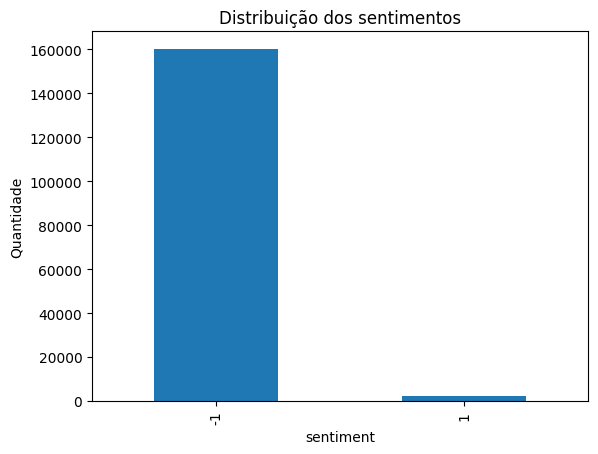

In [ ]:

contagem_sentimento = df_full["sentiment"].value_counts(dropna=False)
print(contagem_sentimento)

contagem_sentimento.plot(kind="bar")
plt.title("Distribuição dos sentimentos")
plt.ylabel("Quantidade")
plt.show()

## 21. Criação da base binária completa

Nesta versão, a base já é naturalmente binária. Ainda assim, mantemos a etapa de filtragem para garantir consistência metodológica.

In [ ]:

df_full_binario = df_full[df_full["sentiment"].isin([1, -1])].copy()
print(df_full_binario["sentiment"].value_counts())

sentiment
-1    160159
 1      2252
Name: count, dtype: int64


## 22. Salvamento da base binária

In [ ]:

salvar_csv(df_full_binario, "03a_full_binario_sst2.csv")

Salvo: /content/drive/MyDrive/artefatos_fase5_full_sst2/03a_full_binario_sst2.csv


# =========================================
# DATA AUGMENTATION DA CLASSE POSITIVA
# =========================================

In [ ]:
# 1. Separar positivos e negativos
df_pos = df_full_binario[df_full_binario["sentiment"] == 1].copy()
df_neg = df_full_binario[df_full_binario["sentiment"] == -1].copy()

print("Positivos reais:", len(df_pos))
print("Negativos reais:", len(df_neg))

# 2. Oversampling dos positivos reais
# aqui vamos multiplicar a classe positiva por amostragem com reposição
n_oversample = 10000

df_pos_over = df_pos.sample(
    n=n_oversample,
    replace=True,
    random_state=42
).copy()

print("Positivos após oversampling:", len(df_pos_over))

# 3. Gerar positivos sintéticos com GPT-2
generator = pipeline(
    "text-generation",
    model="gpt2",
    device=0 if torch.cuda.is_available() else -1
)

prompts = [
    "The company resolved my issue and",
    "The bank service was excellent and",
    "I am satisfied with the support because",
    "The issue was fixed quickly and",
    "Customer service helped me and"
]

novas_frases = []
n_gpt = 3000  # quantidade de frases sintéticas

for i in range(n_gpt):
    prompt = prompts[i % len(prompts)]

    texto = generator(
        prompt,
        max_length=40,
        num_return_sequences=1,
        do_sample=True,
        temperature=0.9,
        top_k=50,
        top_p=0.95
    )[0]["generated_text"]

    novas_frases.append(texto)

df_gpt = pd.DataFrame({
    "narrative": novas_frases,
    "narrative_classic": novas_frases,
    "narrative_dl": novas_frases,
    "sentiment_raw": "POSITIVE",
    "sentiment_score": 1.0,
    "sentiment": 1
})

print("Positivos sintéticos GPT:", len(df_gpt))

# 4. Juntar positivos reais + oversampling + GPT
df_pos_aug = pd.concat([df_pos, df_pos_over, df_gpt], axis=0)
df_pos_aug = shuffle(df_pos_aug, random_state=42).reset_index(drop=True)

print("Total positivos aumentados:", len(df_pos_aug))


Positivos reais: 2252
Negativos reais: 160159
Positivos após oversampling: 10000


config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/548M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


...

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

A saída de streaming foi truncada nas últimas 5000 linhas.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Both `max_new_tokens` (=256) and `max_length`(=40) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Both `max_new_tokens` (=256) and `max_length`(=40) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Both `max_new_tokens` (=256) and `max_length`(=40) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_cla

Positivos sintéticos GPT: 3000
Total positivos aumentados: 15252


# 23. SEPARAÇÃO ENTRE TREINO REAL E TESTE REAL

A base balanceada será utilizada no modelo de Deep Learning e também em um experimento comparativo com o baseline.

In [ ]:
train_real, test_real = train_test_split(
    df_full_binario,
    test_size=0.2,
    stratify=df_full_binario["sentiment"],
    random_state=42
)

print("Treino real:")
print(train_real["sentiment"].value_counts())

print("\nTeste real:")
print(test_real["sentiment"].value_counts())

Treino real:
sentiment
-1    128126
 1      1802
Name: count, dtype: int64

Teste real:
sentiment
-1    32033
 1      450
Name: count, dtype: int64


## 24. Data augmentation da classe positiva no treino

In [ ]:
df_pos = train_real[train_real["sentiment"] == 1].copy()
df_neg = train_real[train_real["sentiment"] == -1].copy()

print("Positivos reais no treino:", len(df_pos))
print("Negativos reais no treino:", len(df_neg))

# oversampling simples da classe positiva
df_pos_over = df_pos.sample(
    n=len(df_neg),
    replace=True,
    random_state=42
).copy()

df_train_balanceado = pd.concat([df_neg, df_pos_over], axis=0)
df_train_balanceado = shuffle(df_train_balanceado, random_state=42).reset_index(drop=True)

print("\nBase de treino balanceada:")
print(df_train_balanceado["sentiment"].value_counts())

Positivos reais no treino: 1802
Negativos reais no treino: 128126

Base de treino balanceada:
sentiment
-1    128126
 1    128126
Name: count, dtype: int64


## 25. Salvar base de treino balanceada

In [ ]:
salvar_csv(df_train_balanceado, "03c_train_balanceado.csv")
salvar_csv(test_real, "03d_test_real.csv")

Salvo: /content/drive/MyDrive/artefatos_fase5_full_sst2/03c_train_balanceado.csv
Salvo: /content/drive/MyDrive/artefatos_fase5_full_sst2/03d_test_real.csv


## **RECOMECE AQUI**
Carregar base balanceada salva
comentar antes da entrega

In [9]:
df_train_balanceado = pd.read_csv(f"{PASTA_PROJETO}/03c_train_balanceado.csv")
test_real = pd.read_csv(f"{PASTA_PROJETO}/03d_test_real.csv")

print("Treino balanceado:")
print(df_train_balanceado["sentiment"].value_counts())

print("\nTeste real:")
print(test_real["sentiment"].value_counts())

Treino balanceado:
sentiment
-1    128126
 1    128126
Name: count, dtype: int64

Teste real:
sentiment
-1    32033
 1      450
Name: count, dtype: int64


## 26. Modelo Baseline — Representação TF-IDF e Regressão Logística

Como ponto de partida, foi construído um modelo baseline utilizando TF-IDF para vetorização textual e Regressão Logística para classificação.  
O objetivo do baseline é estabelecer uma referência de desempenho para comparação com o modelo de Deep Learning.

In [10]:
X_train_bal = df_train_balanceado["narrative_classic"]
y_train_bal = df_train_balanceado["sentiment"]

X_test_bal = test_real["narrative_classic"]
y_test_bal = test_real["sentiment"]

print("Treino baseline:", X_train_bal.shape, y_train_bal.shape)
print("Teste baseline:", X_test_bal.shape, y_test_bal.shape)

Treino baseline: (256252,) (256252,)
Teste baseline: (32483,) (32483,)


## 27. Baseline — TF-IDF

In [11]:
vectorizer_bal = TfidfVectorizer(max_features=5000)
X_train_bal_tfidf = vectorizer_bal.fit_transform(X_train_bal)
X_test_bal_tfidf = vectorizer_bal.transform(X_test_bal)

print("TF-IDF treino:", X_train_bal_tfidf.shape)
print("TF-IDF teste:", X_test_bal_tfidf.shape)

TF-IDF treino: (256252, 5000)
TF-IDF teste: (32483, 5000)


### 28. Baseline — treinamento

In [12]:
baseline_bal = LogisticRegression(
    max_iter=1000,
    class_weight="balanced"
)

baseline_bal.fit(X_train_bal_tfidf, y_train_bal)
y_pred_bal = baseline_bal.predict(X_test_bal_tfidf)
y_prob_bal = baseline_bal.predict_proba(X_test_bal_tfidf)

## 29. Baseline — avaliação

In [13]:
print("Accuracy:", accuracy_score(y_test_bal, y_pred_bal))
print("F1 (negative):", f1_score(y_test_bal, y_pred_bal, pos_label=-1))
print("F1 macro:", f1_score(y_test_bal, y_pred_bal, average="macro"))
print("\nRelatório de classificação:")
print(classification_report(y_test_bal, y_pred_bal))

Accuracy: 0.9367669242372934
F1 (negative): 0.9669721820228333
F1 macro: 0.6135293186771227

Relatório de classificação:
              precision    recall  f1-score   support

          -1       1.00      0.94      0.97     32033
           1       0.16      0.80      0.26       450

    accuracy                           0.94     32483
   macro avg       0.58      0.87      0.61     32483
weighted avg       0.99      0.94      0.96     32483



## 30. Baseline — matriz de confusão

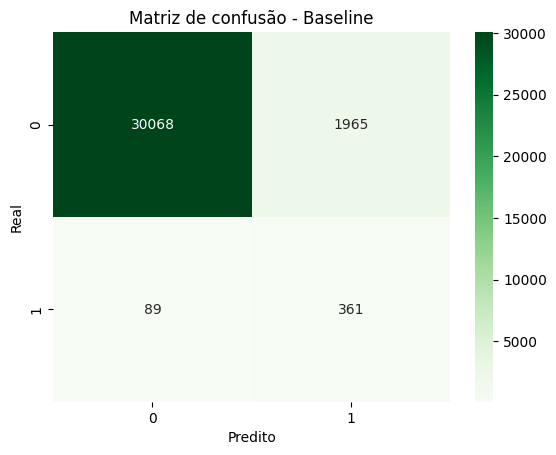

In [14]:
cm_bal = confusion_matrix(y_test_bal, y_pred_bal)
sns.heatmap(cm_bal, annot=True, fmt="d", cmap="Greens")
plt.title("Matriz de confusão - Baseline")
plt.xlabel("Predito")
plt.ylabel("Real")
plt.show()

## 31. Modelo Deep Learning — Tokenização e Sequências

Para capturar relações semânticas mais complexas no texto, foi utilizado um modelo de Deep Learning baseado em redes neurais recorrentes (GRU), que permite analisar a sequência das palavras e o contexto das frases.



In [15]:
X_train_dl_text = df_train_balanceado["narrative_dl"].astype(str)
y_train_dl = df_train_balanceado["sentiment"].map({-1: 0, 1: 1})

X_test_dl_text = test_real["narrative_dl"].astype(str)
y_test_dl = test_real["sentiment"].map({-1: 0, 1: 1})

max_words = 15000
max_len = 100

tokenizer_dl = Tokenizer(num_words=max_words, oov_token="<OOV>")
tokenizer_dl.fit_on_texts(X_train_dl_text)

X_train_seq = tokenizer_dl.texts_to_sequences(X_train_dl_text)
X_test_seq = tokenizer_dl.texts_to_sequences(X_test_dl_text)

X_train_dl = pad_sequences(X_train_seq, maxlen=max_len, padding="post", truncating="post")
X_test_dl = pad_sequences(X_test_seq, maxlen=max_len, padding="post", truncating="post")

print("Treino DL:", X_train_dl.shape, y_train_dl.shape)
print("Teste DL:", X_test_dl.shape, y_test_dl.shape)

Treino DL: (256252, 100) (256252,)
Teste DL: (32483, 100) (32483,)


## 32. Deep Learning — pesos das classes

In [16]:

from sklearn.utils.class_weight import compute_class_weight
import numpy as np

classes = np.unique(y_train_dl)

weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train_dl
)

class_weights = dict(zip(classes, weights))
print("Pesos das classes:", class_weights)

Pesos das classes: {np.int64(0): np.float64(1.0), np.int64(1): np.float64(1.0)}


## 33. Deep Learning — criação do modelo GRU

In [17]:
model_dl = Sequential([
    Embedding(input_dim=max_words, output_dim=128, input_length=max_len),
    GRU(64),
    Dense(32, activation="relu"),
    Dropout(0.3),
    Dense(1, activation="sigmoid")
])

model_dl.compile(
    loss="binary_crossentropy",
    optimizer="adam",
    metrics=["accuracy"]
)

model_dl.summary()

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=2,
    restore_best_weights=True
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

## 34. Deep Learning — treinamento

In [18]:
history = model_dl.fit(
    X_train_dl,
    y_train_dl,
    validation_split=0.2,
    epochs=5,
    batch_size=64,
    callbacks=[early_stop],
    class_weight=class_weights,
    verbose=1
)

Epoch 1/5
3204/3204 ━━━━━━━━━━━━━━━━━━━━ 547s 170ms/step - accuracy: 0.9564 - loss: 0.1079 - val_accuracy: 0.9948 - val_loss: 0.0225
Epoch 2/5
3204/3204 ━━━━━━━━━━━━━━━━━━━━ 556s 168ms/step - accuracy: 0.9955 - loss: 0.0206 - val_accuracy: 0.9958 - val_loss: 0.0181
Epoch 3/5
3204/3204 ━━━━━━━━━━━━━━━━━━━━ 564s 176ms/step - accuracy: 0.9974 - loss: 0.0119 - val_accuracy: 0.9971 - val_loss: 0.0142
Epoch 4/5
3204/3204 ━━━━━━━━━━━━━━━━━━━━ 613s 173ms/step - accuracy: 0.9983 - loss: 0.0080 - val_accuracy: 0.9973 - val_loss: 0.0153
Epoch 5/5
3204/3204 ━━━━━━━━━━━━━━━━━━━━ 537s 168ms/step - accuracy: 0.9989 - loss: 0.0051 - val_accuracy: 0.9975 - val_loss: 0.0129


## 35. Deep Learning — avaliação

In [19]:
y_prob_dl = model_dl.predict(X_test_dl).ravel()
y_pred_dl = (y_prob_dl > 0.5).astype(int)

print("Accuracy DL:", accuracy_score(y_test_dl, y_pred_dl))
print("F1 macro DL:", f1_score(y_test_dl, y_pred_dl, average="macro"))
print("\nRelatório DL:")
print(classification_report(y_test_dl, y_pred_dl))

1016/1016 ━━━━━━━━━━━━━━━━━━━━ 19s 18ms/step
Accuracy DL: 0.9905181171689807
F1 macro DL: 0.812502623713331

Relatório DL:
              precision    recall  f1-score   support

           0       0.99      1.00      1.00     32033
           1       0.69      0.58      0.63       450

    accuracy                           0.99     32483
   macro avg       0.84      0.79      0.81     32483
weighted avg       0.99      0.99      0.99     32483



## 36. Deep Learning — matriz de confusão

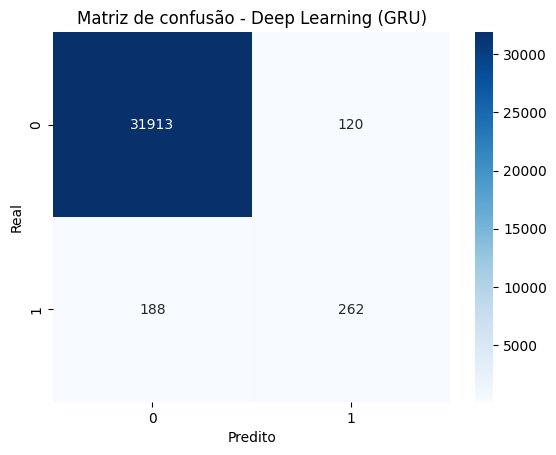

In [20]:
cm_dl = confusion_matrix(y_test_dl, y_pred_dl)
sns.heatmap(cm_dl, annot=True, fmt="d", cmap="Blues")
plt.title("Matriz de confusão - Deep Learning (GRU)")
plt.xlabel("Predito")
plt.ylabel("Real")
plt.show()


## 37. Deep Learning — análise completa

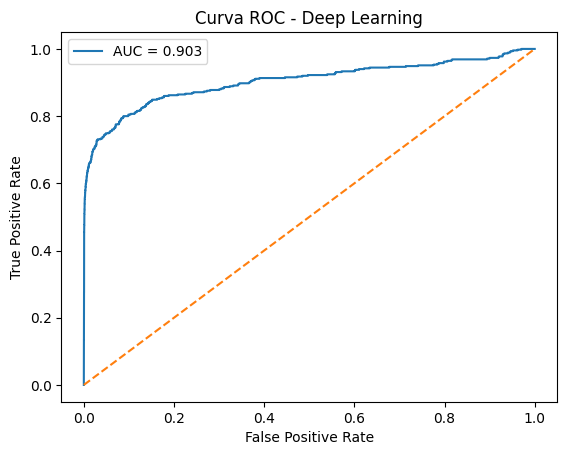

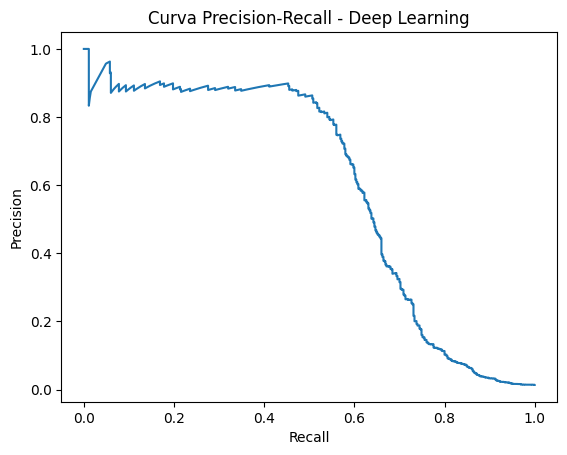

In [21]:
# ROC Curve
fpr, tpr, _ = roc_curve(y_test_dl, y_prob_dl)
auc = roc_auc_score(y_test_dl, y_prob_dl)

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.title("Curva ROC - Deep Learning")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

# Precision-Recall Curve
precision, recall, _ = precision_recall_curve(y_test_dl, y_prob_dl)

plt.figure()
plt.plot(recall, precision)
plt.title("Curva Precision-Recall - Deep Learning")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.show()

## 38. Deep Learning — ajuste de threshold

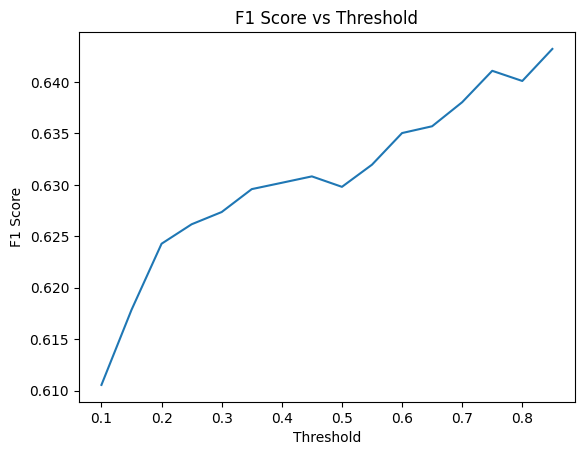

Melhor threshold: 0.8500000000000002

Relatório com melhor threshold:
              precision    recall  f1-score   support

           0       0.99      1.00      1.00     32033
           1       0.74      0.57      0.64       450

    accuracy                           0.99     32483
   macro avg       0.87      0.78      0.82     32483
weighted avg       0.99      0.99      0.99     32483



In [22]:
thresholds = np.arange(0.1, 0.9, 0.05)
f1_scores = []

for t in thresholds:
    y_pred_t = (y_prob_dl > t).astype(int)
    f1 = f1_score(y_test_dl, y_pred_t)
    f1_scores.append(f1)

plt.plot(thresholds, f1_scores)
plt.title("F1 Score vs Threshold")
plt.xlabel("Threshold")
plt.ylabel("F1 Score")
plt.show()

best_threshold = thresholds[np.argmax(f1_scores)]
print("Melhor threshold:", best_threshold)

y_pred_dl_best = (y_prob_dl > best_threshold).astype(int)

print("\nRelatório com melhor threshold:")
print(classification_report(y_test_dl, y_pred_dl_best))

## 39. Comparação entre os Modelos

Nesta etapa, comparamos o desempenho do modelo baseline e do modelo de Deep Learning utilizando métricas como:

- Acurácia
- Precision
- Recall
- F1-score
- ROC-AUC
- Precision-Recall

O objetivo é avaliar se o modelo de Deep Learning realmente apresenta ganho de desempenho em relação ao baseline.

In [23]:
comparacao_modelos = pd.DataFrame({
    "Modelo": ["Baseline - Logistic Regression", "Deep Learning - GRU"],
    "Accuracy": [
        accuracy_score(y_test_bal, y_pred_bal),
        accuracy_score(y_test_dl, y_pred_dl)
    ],
    "F1_macro": [
        f1_score(y_test_bal, y_pred_bal, average="macro"),
        f1_score(y_test_dl, y_pred_dl, average="macro")
    ]
})

comparacao_modelos

,Modelo,Accuracy,F1_macro
0,Baseline - Logistic Regression,0.936767,0.613529
1,Deep Learning - GRU,0.990518,0.812503


## 40. Foco analítico nas reclamações negativas

Como o objetivo do projeto é entender as principais dores dos clientes, a análise foi concentrada nas reclamações com sentimento negativo.

A partir dessas reclamações, foram realizadas as seguintes análises:

- Produtos com maior volume de reclamações
- Palavras mais frequentes nas reclamações
- Bigramas (pares de palavras) mais frequentes
- Nuvem de palavras
- Frequência de reclamações por produto

Essa análise permite identificar padrões de problemas relatados pelos clientes e direcionar ações de melhoria.

In [29]:
# carregar arquivo salvo
df_full = pd.read_csv(f"{PASTA_PROJETO}/03_full_com_sentimento_sst2.csv") # comentar antes da entrega

negative_df = df_full[df_full["sentiment"] == -1].copy()
print("Dimensão de negative_df:", negative_df.shape)
negative_df.head()

Dimensão de negative_df: (160159, 7)


,product,narrative,narrative_classic,narrative_dl,sentiment_raw,sentiment_score,sentiment
0,mortgages_and_loans,called acima ask bill hold payment told date p...,called acima ask bill hold payment told date p...,called acima ask bill hold payment told date p...,NEGATIVE,0.995402,-1
1,credit_reporting,sent letter regarding inaccurate unknown thing...,sent letter regarding inaccurate unknown thing...,sent letter regarding inaccurate unknown thing...,NEGATIVE,0.997132,-1
2,mortgages_and_loans,purchased new vehicle alabama purchase price n...,purchased new vehicle alabama purchase price n...,purchased new vehicle alabama purchase price n...,NEGATIVE,0.994113,-1
3,debt_collection,contacted many time failed provide necessary d...,contacted many time failed provide necessary d...,contacted many time failed provide necessary d...,NEGATIVE,0.998356,-1
4,credit_card,cancellation trip emailed stating charge done ...,cancellation trip emailed stating charge done ...,cancellation trip emailed stating charge done ...,NEGATIVE,0.997209,-1


## 41. Salvar reclamações negativas

In [30]:

salvar_csv(negative_df, "10_negative_full.csv")

Salvo: /content/drive/MyDrive/artefatos_fase5_full_sst2/10_negative_full.csv


## 42. Produtos com mais reclamações negativas

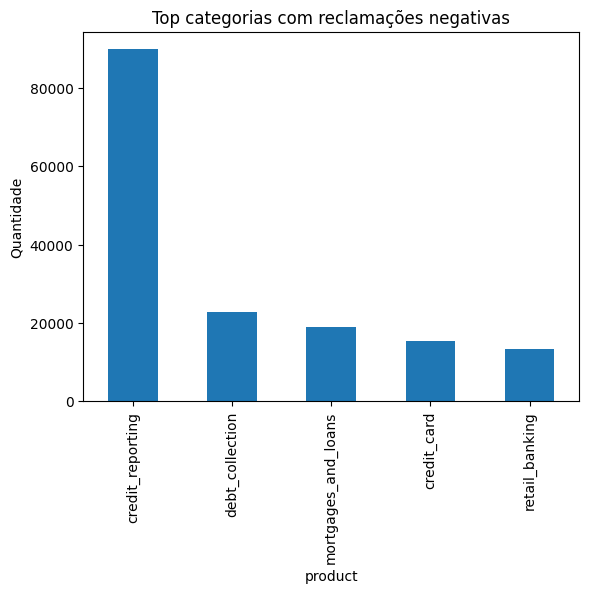

In [31]:
negative_df["product"].value_counts().head(10).plot(kind="bar")
plt.title("Top categorias com reclamações negativas")
plt.ylabel("Quantidade")
plt.show()

## 43. Palavras mais frequentes

In [32]:

all_words = " ".join(negative_df["narrative_classic"])
word_freq = Counter(all_words.split())

top_words_df = pd.DataFrame(word_freq.most_common(20), columns=["word", "freq"])
top_words_df

,word,freq
0,credit,315828
1,account,314199
2,report,176188
3,information,143201
4,payment,126935
5,reporting,94213
6,time,82487
7,company,79092
8,would,77940
9,day,76747


## 44. Salvar palavras

In [33]:
salvar_csv(top_words_df, "11_top_words_negative_full.csv")

Salvo: /content/drive/MyDrive/artefatos_fase5_full_sst2/11_top_words_negative_full.csv



## 45. Nuvem de palavras e Bigramas das reclamações negativas

## 40. Foco analítico nas reclamações negativas

Como o objetivo do projeto é entender as principais dores dos clientes, a análise foi concentrada nas reclamações com sentimento negativo.

A partir dessas reclamações, foram realizadas as seguintes análises:

- Produtos com maior volume de reclamações
- Palavras mais frequentes nas reclamações
- Bigramas (pares de palavras) mais frequentes
- Nuvem de palavras
- Frequência de reclamações por produto

Essa análise permite identificar padrões de problemas relatados pelos clientes e direcionar ações de melhoria.

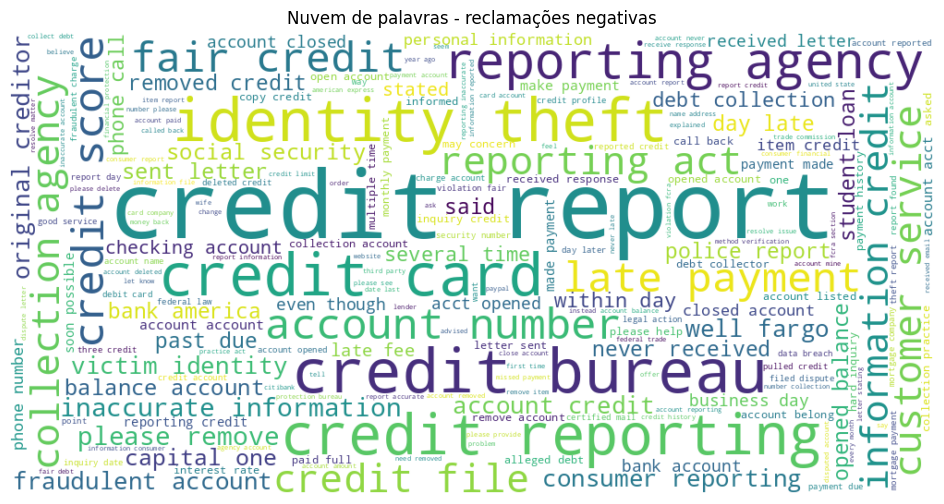

In [34]:
wordcloud = WordCloud(width=1000, height=500, background_color="white").generate(all_words)

plt.figure(figsize=(12, 6))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Nuvem de palavras - reclamações negativas")
plt.show()

In [35]:
vectorizer_bigram = CountVectorizer(
    stop_words="english",
    ngram_range=(2, 2),
    max_features=20
)

X_bigram = vectorizer_bigram.fit_transform(negative_df["narrative_classic"])

bigram_freq = pd.DataFrame({
    "Bigram": vectorizer_bigram.get_feature_names_out(),
    "Frequência": X_bigram.sum(axis=0).A1
}).sort_values(by="Frequência", ascending=False)

bigram_freq

,Bigram,Frequência
7,credit report,98734
4,credit bureau,31220
13,identity theft,28964
5,credit card,28082
8,credit reporting,26622
18,reporting agency,20434
9,credit score,15327
1,account number,14774
16,late payment,14401
11,fair credit,14348


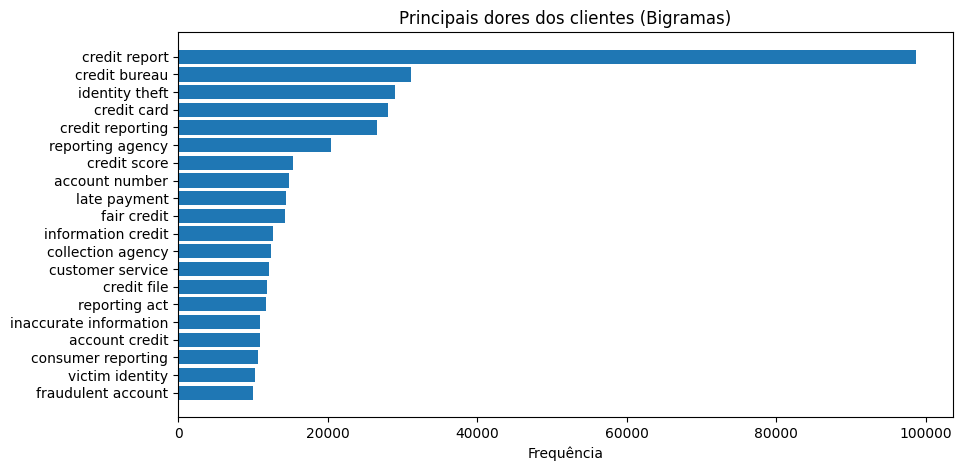

In [36]:
plt.figure(figsize=(10,5))
plt.barh(bigram_freq["Bigram"], bigram_freq["Frequência"])
plt.gca().invert_yaxis()
plt.title("Principais dores dos clientes (Bigramas)")
plt.xlabel("Frequência")
plt.show()

In [37]:
salvar_csv(bigram_freq, "13_bigramas_reclamacoes.csv")

Salvo: /content/drive/MyDrive/artefatos_fase5_full_sst2/13_bigramas_reclamacoes.csv


## 46. Frequência por produto

In [48]:
freq_por_produto = {}

for prod in negative_df["product"].value_counts().index:
    texto = " ".join(negative_df[negative_df["product"] == prod]["narrative_classic"])
    freq = Counter(texto.split()).most_common(10)
    freq_por_produto[prod] = freq

    print(f"\nProduto: {prod}")
    print(freq)


Produto: credit_reporting
[('credit', 223282), ('account', 187463), ('report', 143761), ('information', 107321), ('reporting', 80037), ('consumer', 50164), ('payment', 45378), ('dispute', 42314), ('letter', 38988), ('day', 38897)]

Produto: debt_collection
[('debt', 42512), ('credit', 38983), ('account', 34262), ('collection', 22087), ('report', 20527), ('company', 18795), ('information', 16173), ('letter', 12382), ('payment', 11902), ('received', 11888)]

Produto: mortgages_and_loans
[('payment', 47133), ('loan', 44079), ('mortgage', 26487), ('would', 22515), ('account', 19013), ('time', 18275), ('credit', 15828), ('told', 15611), ('company', 14498), ('received', 14289)]

Produto: credit_card
[('card', 37723), ('credit', 33084), ('account', 28326), ('payment', 17731), ('bank', 14025), ('charge', 13830), ('would', 12959), ('time', 12562), ('one', 11272), ('received', 10237)]

Produto: retail_banking
[('account', 45135), ('bank', 25848), ('money', 15906), ('would', 10462), ('day', 9898

##47. Transformar frequências em tabela

In [49]:

linhas_freq_produto = []

for prod, lista_freq in freq_por_produto.items():
    for palavra, frequencia in lista_freq:
        linhas_freq_produto.append({
            "product": prod,
            "word": palavra,
            "freq": frequencia
        })

freq_produto_df = pd.DataFrame(linhas_freq_produto)
freq_produto_df

,product,word,freq
0,credit_reporting,credit,223282
1,credit_reporting,account,187463
2,credit_reporting,report,143761
3,credit_reporting,information,107321
4,credit_reporting,reporting,80037
5,credit_reporting,consumer,50164
6,credit_reporting,payment,45378
7,credit_reporting,dispute,42314
8,credit_reporting,letter,38988
9,credit_reporting,day,38897


## 48. Salvar frequências por produto

In [50]:
salvar_csv(freq_produto_df, "12_freq_por_produto_full.csv")

Salvo: /content/drive/MyDrive/artefatos_fase5_full_sst2/12_freq_por_produto_full.csv


## 49. Gráficos por produto

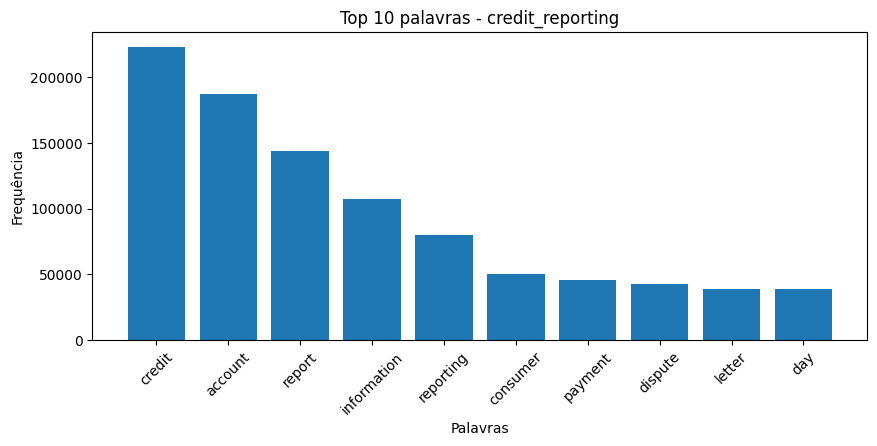

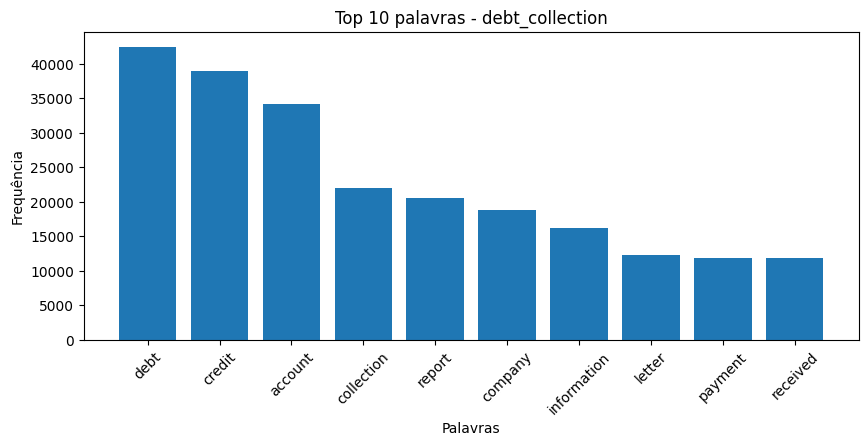

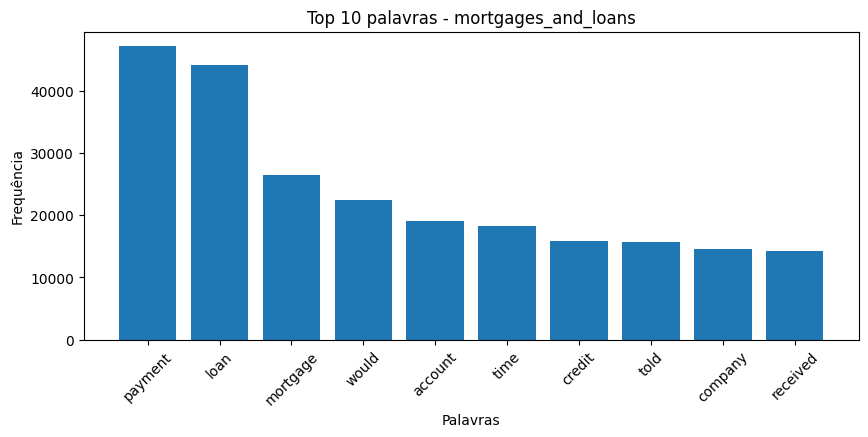

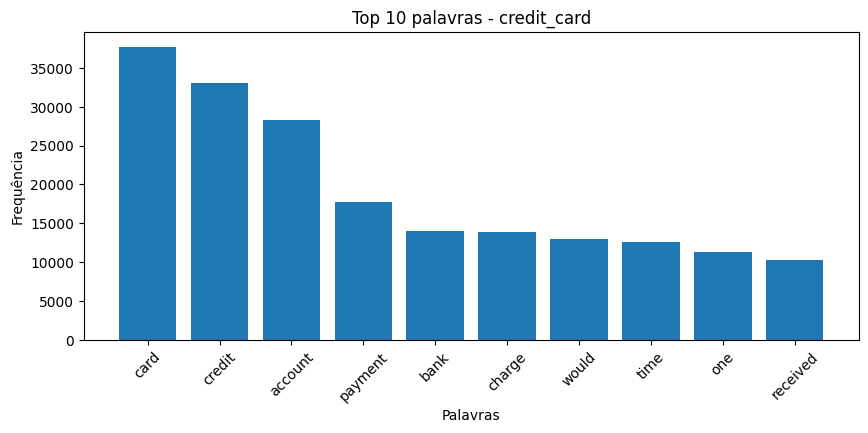

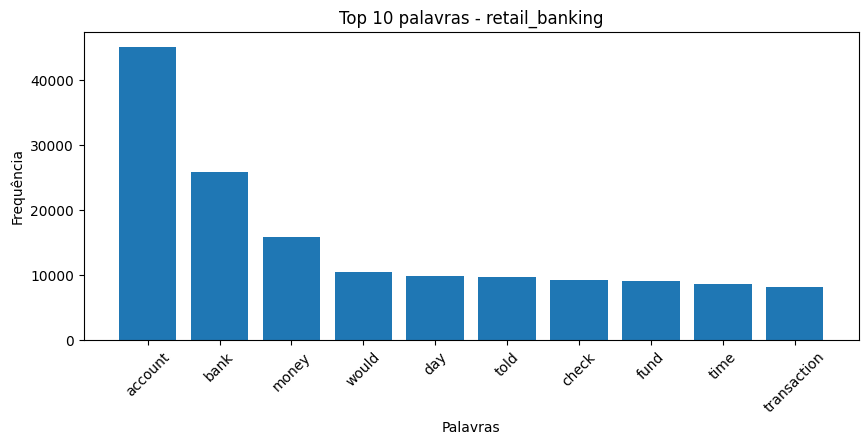

In [51]:
for prod in freq_produto_df["product"].unique():
    temp = freq_produto_df[freq_produto_df["product"] == prod]
    temp = temp.sort_values(by="freq", ascending=False).head(10)

    plt.figure(figsize=(10, 4))
    plt.bar(temp["word"], temp["freq"])
    plt.title(f"Top 10 palavras - {prod}")
    plt.xticks(rotation=45)
    plt.ylabel("Frequência")
    plt.xlabel("Palavras")
    plt.show()

## 50. Conclusão

A análise das reclamações permitiu identificar padrões importantes no comportamento e na insatisfação dos clientes em relação aos produtos e serviços financeiros.

A classificação de sentimento mostrou que a maior parte das reclamações possui sentimento negativo, indicando um alto nível de insatisfação dos clientes com os serviços analisados.

A análise textual das reclamações negativas permitiu identificar os principais temas de insatisfação, com destaque para problemas relacionados a:

- Cobranças indevidas
- Taxas e juros
- Problemas com cartão de crédito
- Atendimento ao cliente
- Empréstimos e financiamentos
- Demora na resolução de problemas

A análise por categoria de produto mostrou que alguns produtos concentram maior volume de reclamações, indicando áreas prioritárias para melhoria.

Do ponto de vista de negócio, os resultados indicam que a empresa deve priorizar melhorias nos processos relacionados a cobrança, atendimento ao cliente e gestão de crédito, pois esses temas concentram a maior parte das reclamações e impactam diretamente a satisfação dos clientes.

Além disso, o uso de modelos de Machine Learning e Deep Learning permite automatizar a classificação de sentimento em grandes volumes de reclamações, possibilitando que a empresa monitore a satisfação dos clientes em tempo real e identifique rapidamente novos problemas.

In [43]:
print("Conclusão técnica:")
print("- A base completa foi rotulada com DistilBERT SST-2.")
print("- O treino foi balanceado por oversampling da classe positiva.")
print("- O teste foi realizado com base com distribuição real das classes.")
print("- Foram comparados um baseline com TF-IDF + Regressão Logística e um modelo de Deep Learning com GRU.")
print("- A análise de negócio foi focada nas reclamações negativas e nos produtos mais críticos.")

Conclusão técnica:
- A base completa foi rotulada com DistilBERT SST-2.
- O treino foi balanceado por oversampling da classe positiva.
- O teste foi realizado com base com distribuição real das classes.
- Foram comparados um baseline com TF-IDF + Regressão Logística e um modelo de Deep Learning com GRU.
- A análise de negócio foi focada nas reclamações negativas e nos produtos mais críticos.
